In [1]:
# ── Dataset 2: Student Depression ───────────────────────────────
# Best model: XGBoost (CV Macro F1: 0.841, AUC: 0.921)
# Task: Binary classification (0 = not depressed, 1 = depressed)

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

df_ml = pd.read_csv("../../data/processed/student_depression_ml.csv")

# Reproduce exact preprocessing from baseline notebook
city_cols = [col for col in df_ml.columns if col.startswith("City_")]
df_ml = df_ml.drop(columns=city_cols)

df_ml = df_ml[df_ml["Profession_student"] == 1].copy()
profession_cols = [col for col in df_ml.columns if col.startswith("Profession_")]
df_ml = df_ml.drop(columns=profession_cols)

work_pressure_cols = [col for col in df_ml.columns
                      if "Work Pressure" in col or "work_pressure" in col.lower()]
df_ml = df_ml.drop(columns=work_pressure_cols, errors="ignore")

job_sat_cols = [col for col in df_ml.columns
                if "Job Satisfaction" in col or "job_satisfaction" in col.lower()]
df_ml = df_ml.drop(columns=job_sat_cols, errors="ignore")

REFERENCE_COLS = [
    "Gender_male",
    "Sleep Duration_7-8 hours",
    "Dietary Habits_Moderate",
    "Degree_bachelor",
    "Have you ever had suicidal thoughts ?_no",
    "Family History of Mental Illness_no",
]
df_ml = df_ml.drop(columns=[c for c in REFERENCE_COLS if c in df_ml.columns])

X = df_ml.drop(columns=["Depression_yes"])
y = df_ml["Depression_yes"]

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Class balance: {y.value_counts(normalize=True).round(3).to_dict()}")

X shape: (27870, 23), y shape: (27870,)
Class balance: {1: 0.585, 0: 0.415}


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb_sd = XGBClassifier(
    objective="binary:logistic",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_sd.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [3]:
# SHAP for XGBoost binary classification
explainer_sd = shap.TreeExplainer(xgb_sd)

X_sample_sd = X_test.sample(n=min(500, len(X_test)), random_state=42)

shap_values_sd = explainer_sd.shap_values(X_sample_sd)

print(f"SHAP values shape: {shap_values_sd.shape}")
# Expected: (n_samples, n_features) for binary XGBoost

SHAP values shape: (500, 23)


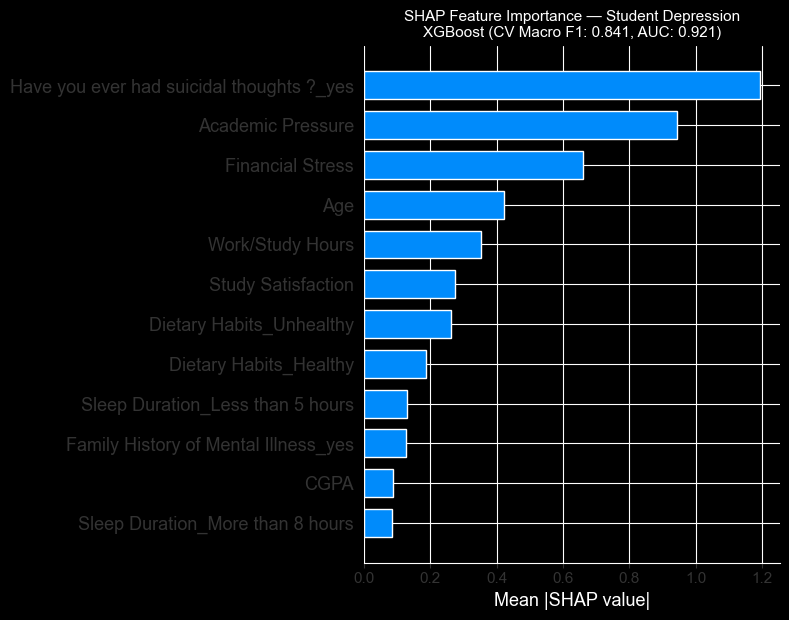

Saved: shap_student_depression_bar.png


In [4]:
# Bar plot — global feature importance
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values_sd,
    X_sample_sd,
    plot_type="bar",
    max_display=12,
    show=False,
)
plt.title(
    "SHAP Feature Importance — Student Depression\n"
    "XGBoost (CV Macro F1: 0.841, AUC: 0.921)",
    fontsize=11
)
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.savefig("../../outputs/shap/shap_student_depression_bar.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_student_depression_bar.png")

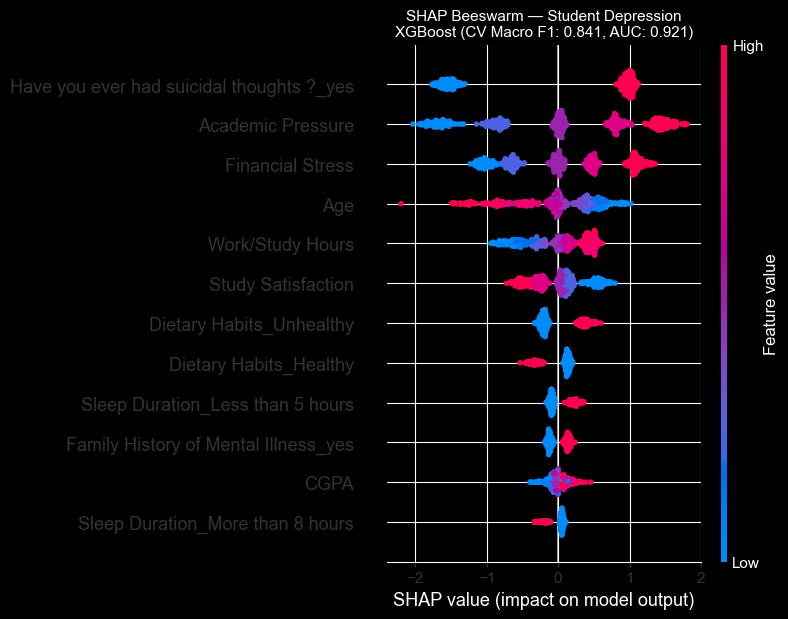

Saved: shap_student_depression_beeswarm.png


In [5]:
# Beeswarm plot — direction and magnitude of each feature
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_sd,
    X_sample_sd,
    max_display=12,
    show=False
)
plt.title(
    "SHAP Beeswarm — Student Depression\n"
    "XGBoost (CV Macro F1: 0.841, AUC: 0.921)",
    fontsize=11
)
plt.tight_layout()
plt.savefig("../../outputs/shap/shap_student_depression_beeswarm.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_student_depression_beeswarm.png")

In [6]:
# Sensitivity analysis — model without suicidal ideation feature
# This tests whether the model retains predictive power when the
# co-symptom predictor is removed

X_no_sui = X.drop(columns=[
    "Have you ever had suicidal thoughts ?_yes"
], errors="ignore")

X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X_no_sui, y, test_size=0.2, random_state=42, stratify=y
)

xgb_sd_ns = XGBClassifier(
    objective="binary:logistic",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_sd_ns.fit(X_train_ns, y_train_ns)

from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import cross_val_predict, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_prob_ns = cross_val_predict(
    xgb_sd_ns, X_no_sui, y,
    cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

auc_ns  = roc_auc_score(y, y_prob_ns)

y_pred_ns = cross_val_predict(
    xgb_sd_ns, X_no_sui, y,
    cv=cv, method="predict", n_jobs=-1
)

f1_ns = f1_score(y, y_pred_ns, average="macro")

print("Sensitivity Analysis — Without Suicidal Ideation Feature")
print(f"CV Macro F1 (with suicidal ideation)    : 0.841")
print(f"CV Macro F1 (without suicidal ideation) : {f1_ns:.3f}")
print(f"AUC (with suicidal ideation)            : 0.921")
print(f"AUC (without suicidal ideation)         : {auc_ns:.3f}")
print(f"\nF1 drop  : {0.841 - f1_ns:.3f}")
print(f"AUC drop : {0.921 - auc_ns:.3f}")

Sensitivity Analysis — Without Suicidal Ideation Feature
CV Macro F1 (with suicidal ideation)    : 0.841
CV Macro F1 (without suicidal ideation) : 0.791
AUC (with suicidal ideation)            : 0.921
AUC (without suicidal ideation)         : 0.873

F1 drop  : 0.050
AUC drop : 0.048


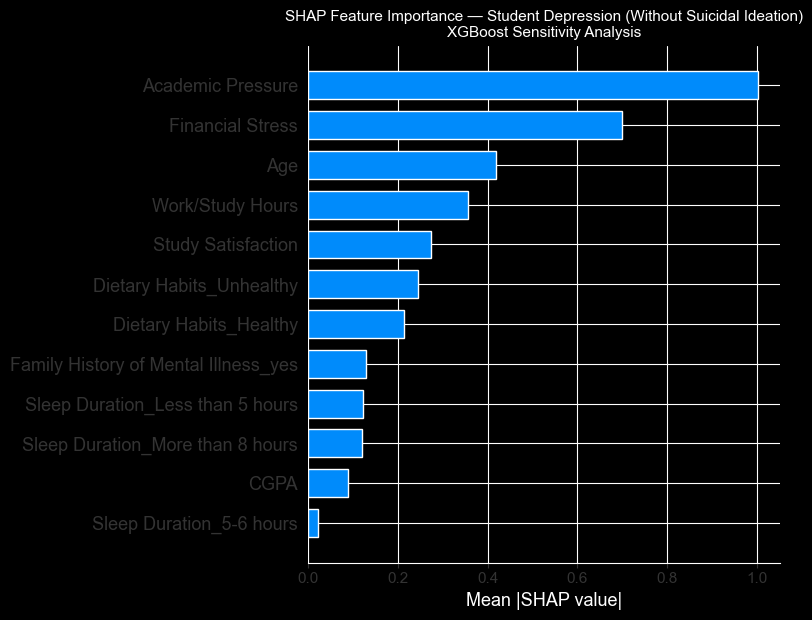

Saved: shap_student_depression_bar_nosui.png


In [7]:
# SHAP for model without suicidal ideation — compare top features
explainer_sd_ns = shap.TreeExplainer(xgb_sd_ns)

X_sample_ns = X_test_ns.sample(n=min(500, len(X_test_ns)), random_state=42)
shap_values_ns = explainer_sd_ns.shap_values(X_sample_ns)

plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values_ns,
    X_sample_ns,
    plot_type="bar",
    max_display=12,
    show=False,
)
plt.title(
    "SHAP Feature Importance — Student Depression (Without Suicidal Ideation)\n"
    "XGBoost Sensitivity Analysis",
    fontsize=11
)
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.savefig("../../outputs/shap/shap_student_depression_bar_nosui.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_student_depression_bar_nosui.png")

In [ ]:
# ### SHAP Analysis — Student Depression (XGBoost)
#
# **Global feature importance:** Suicidal ideation dominates with a
# mean |SHAP| of ~1.22, nearly 30% higher than the second predictor
# (Academic Pressure, ~0.95). Financial Stress (~0.65) ranks third,
# followed by Age (~0.40) and Work/Study Hours (~0.37). The remaining
# features — Study Satisfaction, Dietary Habits, Sleep Duration,
# Family History, and CGPA — contribute meaningfully but at
# substantially lower magnitudes.
#
# **Direction of effects (beeswarm):** The beeswarm plot reveals
# clear directional patterns for all top predictors:
# - Suicidal ideation: high values (red) produce large positive SHAP
#   values (~1.5), strongly increasing depression probability.
#   Low values (blue) produce near-zero SHAP, confirming it acts
#   as a one-directional risk amplifier rather than a symmetric
#   predictor.
# - Academic Pressure: a clear gradient — high pressure (red) pushes
#   strongly toward depression, low pressure (blue) pushes away.
#   The spread is wide, indicating this feature varies substantially
#   across individuals.
# - Financial Stress: similar gradient to Academic Pressure, with
#   high stress pushing toward depression.
# - Study Satisfaction: inverted — high satisfaction (red) pushes
#   away from depression (negative SHAP), confirming it is a
#   protective factor.
# - Age: complex pattern with a wide spread and some outliers,
#   suggesting age interacts with other variables rather than
#   having a simple linear effect.
# - Dietary Habits_Unhealthy: presence (red/high) pushes toward
#   depression; Dietary Habits_Healthy pushes away — confirming
#   diet as a bidirectional lifestyle predictor.
#
# **Sensitivity analysis — removing suicidal ideation:**
# When suicidal ideation is removed, CV Macro F1 drops from 0.841
# to 0.791 (Δ = 0.050) and AUC drops from 0.921 to 0.873
# (Δ = 0.048). The model remains substantially predictive,
# confirming that genuine signal exists in the remaining features.
# Academic Pressure becomes the dominant predictor in the reduced
# model (~1.02 mean |SHAP|), followed by Financial Stress (~0.70).
# The feature ranking is otherwise stable — the same variables
# appear in the same order — suggesting the signal structure is
# robust rather than dependent on a single dominant feature.
#
# This result has two implications. First, suicidal ideation
# contributes approximately 6% of F1 performance beyond what
# the remaining features already provide — meaningful but not
# decisive. Second, the model without suicidal ideation is more
# causally interpretable: Academic Pressure and Financial Stress
# as the top predictors of depression align directly with the
# psychological literature on student mental health and represent
# genuine upstream causes rather than co-occurring symptoms.
#
# **Connection to theory:** The SHAP profile is consistent with
# established models of student psychological distress. Academic
# pressure and financial stress are well-documented stressors
# in the university context, while study satisfaction reflects
# engagement and meaning — a protective factor consistent with
# self-determination theory. The prominence of dietary habits
# and sleep duration as secondary predictors aligns with the
# biopsychosocial model of mental health, where lifestyle
# factors mediate the relationship between stressors and
# psychological outcomes.